# Data Exploration — Psychotherapy Dropout Prediction

This notebook explores the synthetic psychotherapy dataset used for dropout prediction. We will inspect basic structure, class balance, key feature distributions, and correlations to build clinical intuition before training any models.

## Imports

Import core analysis libraries and helper functions for generating and inspecting the psychotherapy dataset.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root (containing `src/`) is on the Python path
root_candidates = [os.getcwd(), os.path.abspath(os.path.join(os.getcwd(), ".."))]
for path in root_candidates:
    if os.path.isdir(os.path.join(path, "src")) and path not in sys.path:
        sys.path.append(path)

from src.data_loader import generate_synthetic_data, check_class_balance

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Generate and preview data

Create a synthetic psychotherapy dataset and take a first look at its shape and first few rows to confirm that all expected columns are present.

In [2]:
df = generate_synthetic_data(n_patients=500, seed=42)

print("Data shape:", df.shape)
display(df.head())

Data shape: (500, 10)


,patient_id,phq9_score,session_number,session_frequency_per_month,attendance_consistency,gap_between_sessions_days,mood_rating,age,phq9_change_rate,dropout
0,1,2,3,6.156940,0.062063,48,1,34,0.135623,0
1,2,21,14,7.204820,0.458262,41,7,62,1.087442,1
2,3,18,20,7.447400,0.129030,56,4,19,-0.484528,1
3,4,12,18,4.525430,0.152327,58,3,41,0.350078,0
4,5,12,6,4.641926,0.632283,43,1,60,1.864811,1


## Basic data information

Inspect data types, missing values, and basic descriptive statistics to understand the structure and ranges of each clinical feature.

In [3]:
print("\nData types:\n", df.dtypes)

print("\nMissing values per column:\n", df.isna().sum())

print("\nBasic statistics:\n")
display(df.describe(include="all"))


Data types:
 patient_id                       int64
phq9_score                       int64
session_number                   int64
session_frequency_per_month    float64
attendance_consistency         float64
gap_between_sessions_days        int64
mood_rating                      int64
age                              int64
phq9_change_rate               float64
dropout                          int64
dtype: object

Missing values per column:
 patient_id                     0
phq9_score                     0
session_number                 0
session_frequency_per_month    0
attendance_consistency         0
gap_between_sessions_days      0
mood_rating                    0
age                            0
phq9_change_rate               0
dropout                        0
dtype: int64

Basic statistics:



,patient_id,phq9_score,session_number,session_frequency_per_month,attendance_consistency,gap_between_sessions_days,mood_rating,age,phq9_change_rate,dropout
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.476000,10.618000,4.490720,0.504575,31.666000,5.518000,42.790000,0.027319,0.348000
std,144.481833,8.005348,5.823048,2.076203,0.291522,16.399034,2.884149,15.200263,1.139303,0.476813
min,1.000000,0.000000,1.000000,1.008631,0.000519,3.000000,1.000000,18.000000,-1.989171,0.000000
25%,125.750000,7.000000,5.000000,2.703228,0.246062,17.000000,3.000000,31.000000,-0.983773,0.000000
50%,250.500000,13.000000,11.000000,4.456011,0.492465,30.000000,6.000000,41.000000,0.081459,0.000000
75%,375.250000,20.250000,16.000000,6.343647,0.759080,46.250000,8.000000,56.250000,1.014952,1.000000
max,500.000000,27.000000,20.000000,7.991204,0.999422,60.000000,10.000000,70.000000,1.990670,1.000000


## Class imbalance: dropout vs. non-dropout

Examine how many patients drop out versus stay in treatment. Understanding this imbalance is crucial for model evaluation and for choosing appropriate techniques such as class weighting or SMOTE.

Class balance for target column: dropout
  Class 0: 326 samples (65.20%)
  Class 1: 174 samples (34.80%)


C:\Users\HP\AppData\Local\Temp\ipykernel_1240\3536481284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette=["#4ade80", "#f97373"])


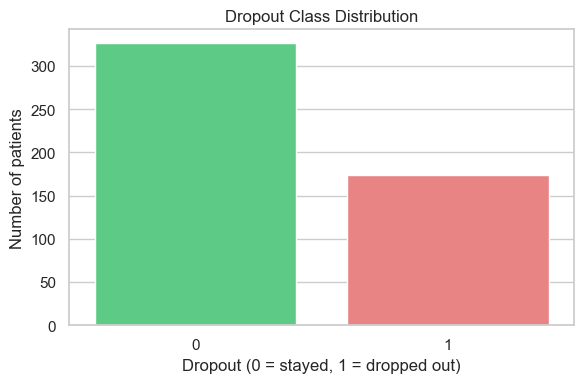

In [4]:
check_class_balance(df, target_col="dropout")

class_counts = df["dropout"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette=["#4ade80", "#f97373"])
plt.title("Dropout Class Distribution")
plt.xlabel("Dropout (0 = stayed, 1 = dropped out)")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.show()

## PHQ-9 score distribution

Visualize the distribution of PHQ-9 depression scores and overlay common clinical severity thresholds to see how patients are spread across mild, moderate, and more severe symptom ranges.

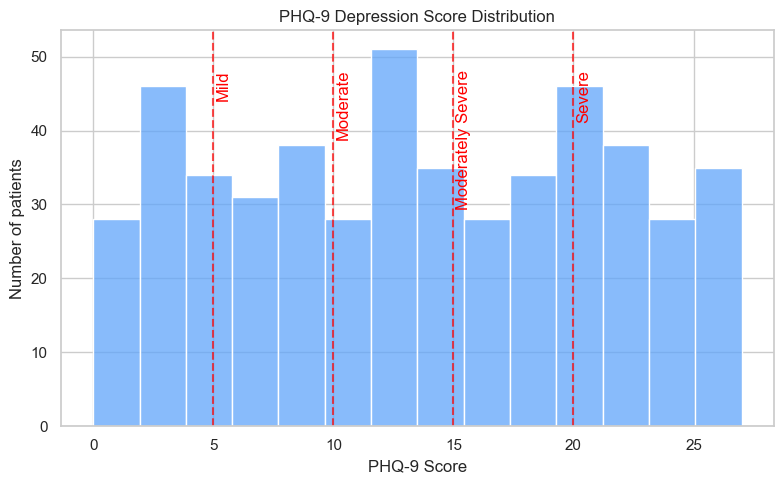

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["phq9_score"], bins=14, kde=False, color="#60a5fa")
plt.title("PHQ-9 Depression Score Distribution")
plt.xlabel("PHQ-9 Score")
plt.ylabel("Number of patients")

thresholds = {
    5: "Mild",
    10: "Moderate",
    15: "Moderately Severe",
    20: "Severe",
}

y_min, y_max = plt.ylim()
for x, label in thresholds.items():
    plt.axvline(x=x, color="red", linestyle="--", alpha=0.7)
    plt.text(x + 0.1, y_max * 0.9, label, rotation=90, color="red", va="top")

plt.tight_layout()
plt.show()

## Feature distributions

Plot distributions of all key numerical features to check for skew, outliers, and clinically plausible ranges. This helps identify potential preprocessing needs and informs model choice.

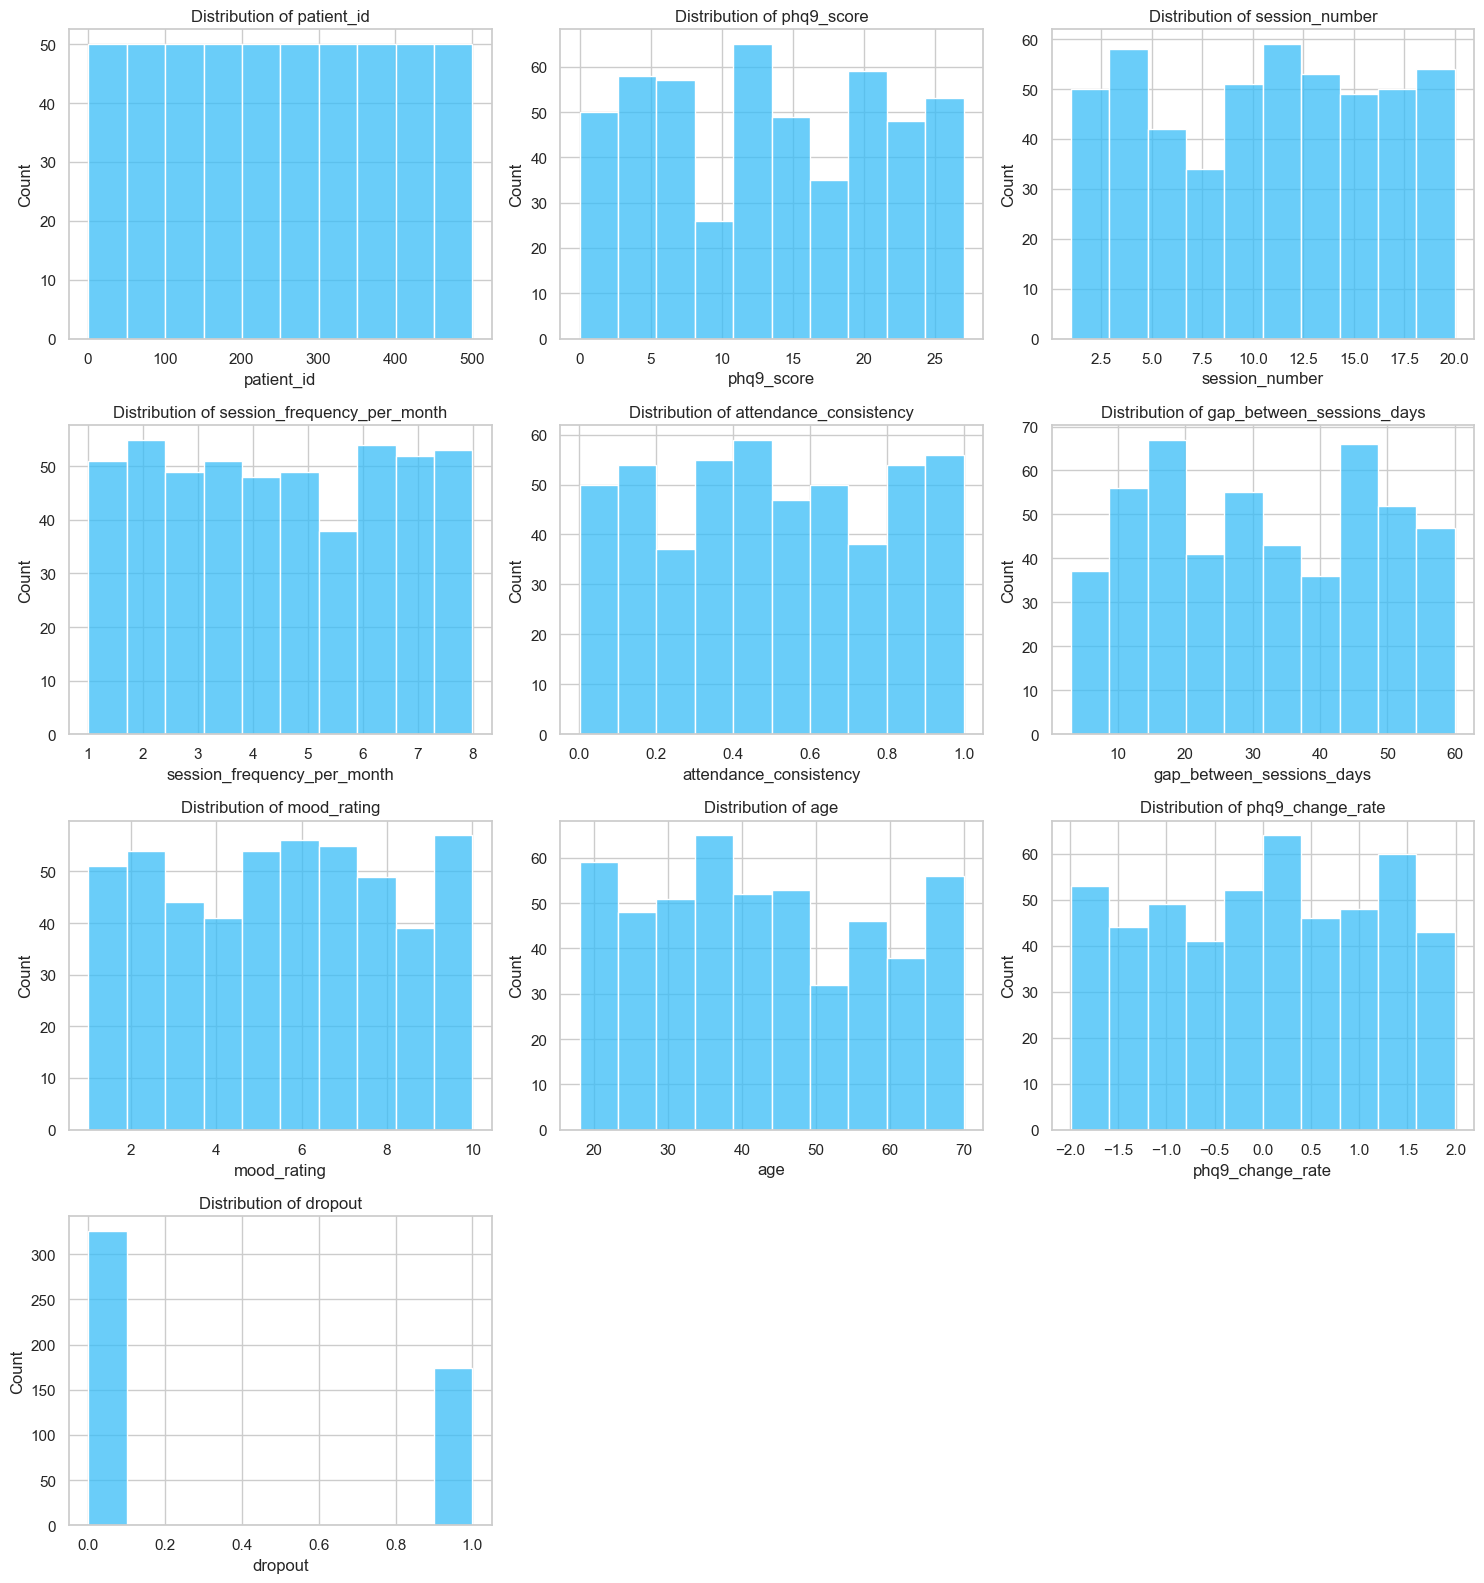

In [6]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for idx, col in enumerate(numeric_cols, start=1):
    plt.subplot(n_rows, n_cols, idx)
    sns.histplot(df[col], kde=False, color="#38bdf8")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Correlation heatmap

Examine correlations between all numerical features, with particular attention to how strongly each feature relates to the dropout outcome. This can highlight clinically meaningful relationships and inform feature engineering.

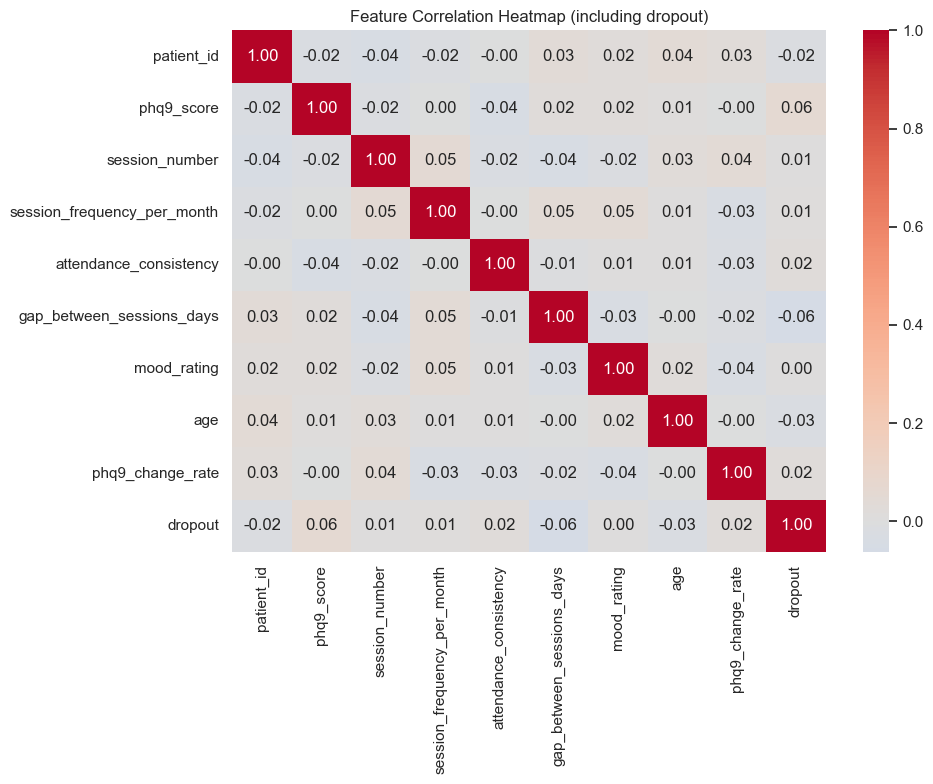


Correlation of each feature with dropout:



dropout                        1.000000
phq9_score                     0.055219
phq9_change_rate               0.024374
attendance_consistency         0.024227
session_frequency_per_month    0.011731
session_number                 0.005390
mood_rating                    0.001265
patient_id                    -0.015737
age                           -0.025012
gap_between_sessions_days     -0.061736
Name: dropout, dtype: float64

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (including dropout)")
plt.tight_layout()
plt.show()

print("\nCorrelation of each feature with dropout:\n")
display(corr["dropout"].sort_values(ascending=False))

## Key clinical observations

Use this section to summarize what you see in the exploratory plots and statistics, focusing on clinical patterns that might relate to dropout risk.

- Which features appear most imbalanced or skewed?
- How are PHQ-9 severity levels distributed across the sample?
- Do dropout patients differ visibly in symptom severity, gaps between sessions, or attendance consistency?
- Which correlations with dropout seem strongest, and do they match clinical expectations?

_Write your reflections here to connect the data back to real-world psychotherapy processes before moving into modeling._

# Data Exploration — Psychotherapy Dropout Prediction

This notebook explores the synthetic psychotherapy dataset used for dropout prediction. We will inspect basic structure, class balance, key feature distributions, and correlations to build clinical intuition before training any models.